Simulated dies         : 10000
Passed                 : 7328
Failed                 : 2672
Combined Vt + W/L yield: 73.28%

--- Sensitivity analysis ---
Both varying (baseline)    : 73.28%
Only Vt varies (W/L fixed) : 76.58%
Only W/L varies (Vt fixed) : 93.31%


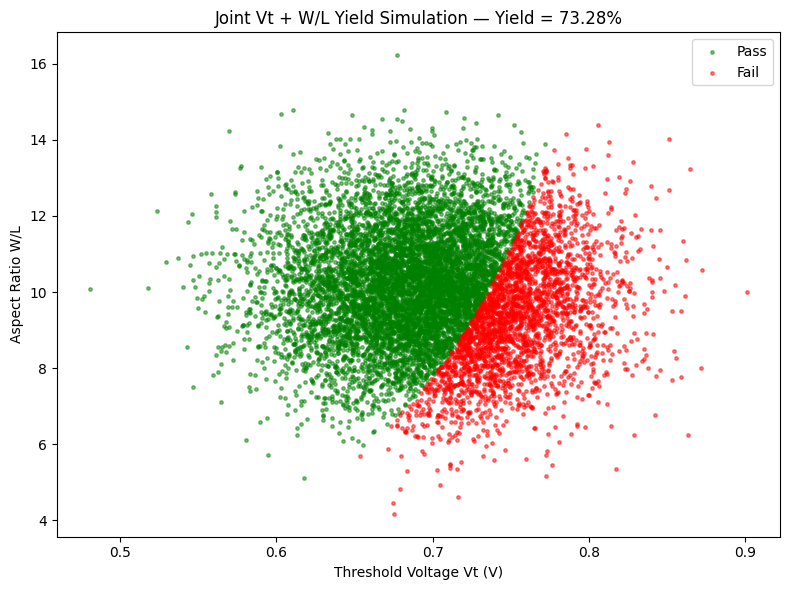

In [ ]:
"""
Semiconductor Yield Estimation — Monte Carlo Simulation (Step 7)
----------------------------------------------------------------------
Now combines TWO process parameters instead of one:
  1. Threshold voltage (Vt)      — as before
  2. Aspect ratio W/L            — the transistor's width-to-length ratio,
                                   which controls how much current it can drive.

Instead of a simple "is Vt in range" check, we now compute the transistor's
actual drive current using both parameters, and a chip only passes if it
turns on AND drives enough current to meet spec.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Process parameters — each one wobbles randomly during manufacturing
# ---------------------------------------------------------------------
mean_vt, std_vt = 0.7, 0.05     # Threshold voltage: target 0.7V, wobble ±0.05V
mean_wl, std_wl = 10.0, 1.5     # Aspect ratio W/L: target 10, wobble ±1.5

# ---------------------------------------------------------------------
# Fixed circuit conditions (these don't vary — they're design constants)
# ---------------------------------------------------------------------
vgs = 1.0        # Gate-source voltage supplied to the transistor (V)
k = 100e-6       # Process transconductance constant (A/V^2) — illustrative value
i_min = 70e-6    # Minimum drive current required for the chip to meet spec (A)

# ---------------------------------------------------------------------
# Run the Monte Carlo simulation with BOTH parameters varying together
# ---------------------------------------------------------------------
n_samples = 10_000
rng = np.random.default_rng(42)

vt_samples = rng.normal(mean_vt, std_vt, n_samples)
wl_samples = rng.normal(mean_wl, std_wl, n_samples)

# W/L can't physically be negative or zero — clip any unrealistic samples
wl_samples = np.clip(wl_samples, 0.1, None)

# "Overdrive voltage" — how far above threshold the gate voltage is.
# If this is <= 0, the transistor never turns on at all.
overdrive = vgs - vt_samples
turns_on = overdrive > 0

# Simplified transistor drive-current equation:
#   I_D = k * (W/L) * (V_GS - V_T)^2
# Only compute current for chips that actually turn on; others get 0 current.
drive_current = np.where(turns_on, k * wl_samples * overdrive**2, 0.0)

# A chip PASSES only if it turns on AND drives enough current to meet spec.
passes = turns_on & (drive_current >= i_min)

n_pass = np.sum(passes)
yield_estimate = n_pass / n_samples

print(f"Simulated dies         : {n_samples}")
print(f"Passed                 : {n_pass}")
print(f"Failed                 : {n_samples - n_pass}")
print(f"Combined Vt + W/L yield: {yield_estimate * 100:.2f}%")

# ---------------------------------------------------------------------
# Sensitivity check — which parameter actually drives yield loss more?
# ---------------------------------------------------------------------
def run_sim(std_vt_local, std_wl_local, n=10_000, seed=42):
    """Re-run the same simulation with custom spreads for Vt and W/L."""
    r = np.random.default_rng(seed)
    vt = r.normal(mean_vt, std_vt_local, n)
    wl = np.clip(r.normal(mean_wl, std_wl_local, n), 0.1, None)
    od = vgs - vt
    on_ = od > 0
    i_d = np.where(on_, k * wl * od**2, 0.0)
    return np.mean(on_ & (i_d >= i_min))

baseline_yield = run_sim(std_vt, std_wl)
vt_only_yield = run_sim(std_vt, 0.001)   # freeze W/L variation, keep Vt variation
wl_only_yield = run_sim(0.001, std_wl)   # freeze Vt variation, keep W/L variation

print("\n--- Sensitivity analysis ---")
print(f"Both varying (baseline)    : {baseline_yield * 100:.2f}%")
print(f"Only Vt varies (W/L fixed) : {vt_only_yield * 100:.2f}%")
print(f"Only W/L varies (Vt fixed) : {wl_only_yield * 100:.2f}%")

# ---------------------------------------------------------------------
# Visualize the JOINT effect of both parameters
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(vt_samples[passes], wl_samples[passes],
            s=6, color="green", alpha=0.5, label="Pass")
plt.scatter(vt_samples[~passes], wl_samples[~passes],
            s=6, color="red", alpha=0.5, label="Fail")
plt.xlabel("Threshold Voltage Vt (V)")
plt.ylabel("Aspect Ratio W/L")
plt.title(f"Joint Vt + W/L Yield Simulation — Yield = {yield_estimate * 100:.2f}%")
plt.legend()
plt.tight_layout()
plt.savefig("yield_joint_scatter.png", dpi=150)
plt.show()


